# Experiment 1B: CCISI — Train-at-f / Eval-at-f Protocol (Learnable Tau)

## Overview

This notebook implements Experiment 1B from the "Beyond Beyond Rate" project
under the **train-at-f / eval-at-f** protocol. For each perturbation level *f*
we instantiate a fresh SNN (with learnable tau, no delays), train it
end-to-end on CCISI with hidden-layer perturbation active on every batch,
then evaluate on the test set at the same *f*.

**CCISI task:** Each sample contains 20 neurons arranged in 10 correlated pairs.
Within each pair, neuron A fires first and neuron B follows with a fixed ISI delay.
The class label is determined jointly by firing rate AND cross-channel ISI,
making this a richer temporal coding task than single-channel ISI.

The hidden-layer perturbation is wired through a **straight-through estimator**
(`_apply_perturbation`) so that ``fc1`` / ``psp_filter`` still receive gradient
signal — the GPU-vectorised ``perturb_hidden_batch`` runs under
``@torch.no_grad()`` and would otherwise sever the autograd graph (Section 7.1
of ``docs/progress/phase1to4_fixes.md``).

| Property | Value |
|---|---|
| Architecture | Input (20) → Hidden (100, SRMALPHA, learnable tau) → Output (2) |
| Training | Fresh model per *f*; perturbation applied at the 1st hidden layer on every batch |
| Evaluation | Same *f* as training; ``NUM_REPEATS`` repeats for error bars |
| Dataset | CCISI synthetic (`ccisi_dataset.h5`), T=1000 time steps |
| Framework | SLAYER (slayerPytorch) |

Compare with `ccisi_delay.ipynb` to see whether learnable delays change the
relationship between *f* and residual accuracy.

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

# Add SLAYER to path (two levels up from this notebook's directory)
CURRENT_DIR = os.getcwd()
sys.path.append(os.path.join(CURRENT_DIR, "../../src"))
import slayerSNN as snn

MS = 1e-3  # Millisecond constant: 1 ms = 1e-3 s

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

SLAYER requires neuron and simulation descriptors.
- `tSample = 1000`: matches the CCISI dataset time steps (1000 ms window).
- `Ts = 1`: 1 ms sampling resolution.
- `SRMALPHA` neurons: spike-response model with alpha-function PSP kernel.

In [2]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 1000}  # 1000 ms sample window
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE   = (0.6, 0.75)
TEST_RANGE  = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS  = 100
EPOCHS        = 301
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
SEED          = 42

# --- Train-at-f / eval-at-f sweep ---
# For each f below a fresh model is instantiated from the same seed and
# trained end-to-end with hidden-layer perturbation active on every batch,
# then evaluated on the test set at the same f with NUM_REPEATS repeats.
F_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS = 3
MODEL_PREFIX = "ccisi_tau"

## 3. Load CCISI Dataset

The CCISI dataset encodes two-class information using cross-channel inter-spike intervals.
Each sample has shape `(num_neurons, T)` with binary spike values.

**Data structure:**
- 20 neurons arranged in 10 pairs (neuron 0/1, 2/3, ..., 18/19).
- Within each pair, neuron A leads; neuron B follows at a fixed ISI.
- Class label reflects the joint (firing_rate, ISI) region in 2D feature space.

In [3]:
def load_ccisi_data(data_file: str = "ccisi.h5"):
    """Load CCISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
        X: (N, num_neurons, T) binary spike trains.
        Y: (N,) integer class labels.
        firing_rates: (N,) firing rate feature per sample (Hz).
        isis: (N,) inter-spike-interval feature per sample (ms).
    """
    with h5py.File(data_file, "r") as f:
        X            = f["X"][:]
        Y            = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis         = f["isis"][:]          if "isis"          in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    if firing_rates is not None:
        print(f"Firing rate range: [{firing_rates.min():.2f}, {firing_rates.max():.2f}] Hz")
    if isis is not None:
        print(f"ISI range: [{isis.min():.1f}, {isis.max():.1f}] ms")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_ccisi_data("ccisi_dataset.h5")
NUM_NEURONS = X_all.shape[1]         # 20 neurons (10 correlated pairs)
NUM_CLASSES = len(np.unique(Y_all))  # 2
print(f"\nNetwork config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded ccisi_dataset.h5: X=(3598, 20, 1000), Y=(3598,)
Classes: [0 1], Time steps: 1000
Firing rate range: [2.00, 10.00] Hz
ISI range: [1.0, 50.0] ms

Network config: 20 input neurons, 2 classes


### 3a. Dataset Visualisation

Plot the 2D feature space (firing rate vs ISI) to confirm the CCISI structure,
and inspect the ISI distribution per class.

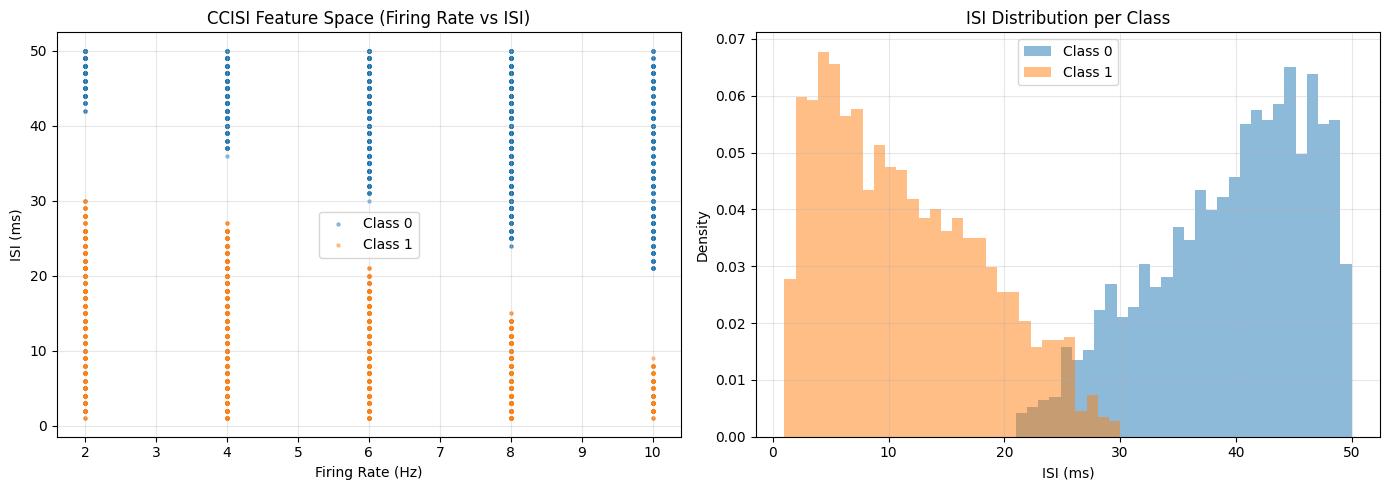

In [4]:
if firing_rates_all is not None and isis_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Feature space scatter: firing rate vs ISI, coloured by class
    for cls, color, label in zip([0, 1], ["tab:blue", "tab:orange"], ["Class 0", "Class 1"]):
        mask = Y_all == cls
        axes[0].scatter(
            firing_rates_all[mask], isis_all[mask],
            s=5, alpha=0.4, color=color, label=label,
        )
    axes[0].set_xlabel("Firing Rate (Hz)")
    axes[0].set_ylabel("ISI (ms)")
    axes[0].set_title("CCISI Feature Space (Firing Rate vs ISI)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ISI histogram per class to show temporal feature separation
    for cls, color, label in zip([0, 1], ["tab:blue", "tab:orange"], ["Class 0", "Class 1"]):
        mask = Y_all == cls
        axes[1].hist(isis_all[mask], bins=30, alpha=0.5, color=color, label=label, density=True)
    axes[1].set_xlabel("ISI (ms)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("ISI Distribution per Class")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. Hidden-Layer Spike Perturbation

The core perturbation mechanism from "Beyond Beyond Rate".
Given a hidden layer's binary spike output of shape `(neurons, T)`, we:
1. For each neuron, randomly select a fraction `f` of its spikes.
2. Remove them from their original positions.
3. Place the same number of spikes at uniformly random (previously-silent) time bins.

This destroys the temporal structure (including cross-channel ISI relationships
between hidden neurons) while **preserving each neuron's total spike count**.
Therefore, any accuracy drop under this perturbation reveals that the hidden
layer was encoding information temporally — not just in firing rates.

In [5]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref impl).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per displaced spike.

    Returns:
        Perturbed spike train with the same shape.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation (§3.6.5 Template A).

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly. All operations stay on the input tensor's device,
    avoiding the CPU/numpy round-trip that dominates training cost when
    perturbation runs on every batch (Section 7.1.3 of
    ``docs/progress/phase1to4_fixes.md``).

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5

    # Count spikes per (batch, neuron) and compute how many to move.
    n_spikes = is_spike.sum(dim=-1, keepdim=True)  # (B, C, 1)
    num_to_move = (n_spikes.float() * f).floor().long()  # (B, C, 1)

    # --- 1. Choose which existing spikes to remove ---
    # Random key per time bin; non-spike bins get +inf so they sort last.
    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    # rank[b, c, t] = position of t in the per-(b,c) ascending sort of `key`.
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move

    keep_mask = is_spike & ~remove_mask

    # --- 2. Place the same number of spikes in currently-unoccupied bins ---
    available = ~keep_mask
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move  # disjoint from keep_mask by construction

    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype)
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A `Dataset` wrapper and helper to create train / validation / test DataLoaders.
Training always uses **unperturbed** data (f=0); perturbation is applied only
at test time inside the network's forward pass.

In [6]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple, total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 32,
) -> tuple:
    """Split data and return (train, val, test) DataLoaders.

    Data is NOT perturbed here — perturbation happens only at inference time
    inside forward_with_hidden_perturbation.

    Args:
        X: Spike-train array (N, num_neurons, T).
        Y: Label array (N,).
        batch_size: Mini-batch size.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    train_idx = get_split_indices(TRAIN_RANGE, len(X))
    val_idx   = get_split_indices(VAL_RANGE,   len(X))
    test_idx  = get_split_indices(TEST_RANGE,  len(X))

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds   = SpikeDataset(X[val_idx],   Y[val_idx])
    test_ds  = SpikeDataset(X[test_idx],  Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    print(f"Split sizes — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A single-hidden-layer SLAYER SNN with a **learnable PSP filter** (no delays).
This is the SGD (tau-only) variant matching the original Beyond Rate architecture.

```
Input (20) → [psp_filter + fc1 + spike] → Hidden (100)
                                                ↓
                            ← perturbation hook (STE) applied here
                                                ↓
                              [psp + fc2 + spike] → Output (2)
```

A single ``forward(x, f)`` routes the hidden spikes through
``_apply_perturbation`` — a straight-through estimator that uses the
perturbed tensor as the forward value but lets gradients flow back through
the unperturbed ``hidden``. ``f=0`` preserves the previous unperturbed
behaviour exactly.

In [7]:
class CCISINetwork(nn.Module):
    """SLAYER SNN for CCISI classification with learnable tau (PSP filter).

    No delay modules — this is the SGD (tau-only) variant. ``forward(x, f)``
    applies the spike-relocation perturbation at the 1st hidden layer
    output through a straight-through estimator so that ``fc1`` and
    ``psp_filter`` still receive gradient when training at ``f > 0``.
    """

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        # Two fully-connected SLAYER layers with weight normalisation
        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # Learnable PSP filter — replaces the fixed-tau PSP for the first layer.
        # filterLength=50: 50-tap FIR approximation of the alpha-function PSP.
        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        self._initialize_alpha_filter()

    # ------------------------------------------------------------------
    # Initialisation helpers
    # ------------------------------------------------------------------

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau      = 50 * MS
        Ts       = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau (s) from the peak of the learned PSP filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx      = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    # ------------------------------------------------------------------
    # Internal layer helpers
    # ------------------------------------------------------------------

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D SLAYER format (N, C, 1, 1, T) on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> hidden spikes through learnable PSP filter + fc1."""
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        """Hidden spikes -> output spikes through standard PSP + fc2."""
        return self.slayer.spike(self.fc2(self.slayer.psp(hidden_spikes)))

    def _apply_perturbation(
        self,
        hidden: torch.Tensor,
        f: float,
    ) -> torch.Tensor:
        """STE wrapper around ``perturb_hidden_batch``.

        ``perturb_hidden_batch`` is decorated with ``@torch.no_grad()`` and
        therefore returns a fresh leaf with no edge in the autograd graph.
        Feeding that directly to ``_second_layer`` would block gradient flow
        to ``fc1`` and ``psp_filter`` for any ``f > 0`` (Section 7.1 of
        ``docs/progress/phase1to4_fixes.md``). The STE keeps the perturbed
        value forward and the identity backward.
        """
        if f <= 0:
            return hidden
        perturbed = perturb_hidden_batch(hidden, f)
        return hidden + (perturbed - hidden).detach()

    # ------------------------------------------------------------------
    # Forward pass
    # ------------------------------------------------------------------

    def forward(self, x: torch.Tensor, f: float = 0.0) -> torch.Tensor:
        """Forward pass with optional hidden-layer perturbation at level *f*."""
        x = self._prepare_input(x)
        hidden = self._first_layer(x)
        hidden = self._apply_perturbation(hidden, f)
        return self._second_layer(hidden)

## 7. Training Loop

Train one model end-to-end with perturbation level *f* active on every
training and validation batch. ProbSpikes loss; Nadam optimiser with the
PSP filter at ×10 LR; multi-step LR schedule. Best checkpoint by
validation loss is restored.

In [8]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
    f: float = 0.0,
) -> tuple:
    """Train the CCISINetwork with perturbation level *f* active on every batch.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        num_neurons: Number of input neurons.
        num_classes: Number of output classes.
        hidden_units: Hidden layer size.
        epochs: Number of training epochs.
        lr: Base learning rate.
        seed: Random seed; re-seeded inside so each f starts from the same init.
        f: Hidden-layer perturbation level applied during forward passes.

    Returns:
        Tuple of (trained CCISINetwork, training log dict).
    """
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = CCISINetwork(num_neurons, num_classes, hidden_units).to(device)

    # SLAYER ProbSpikes loss
    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron":     LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training":   {"error": {"type": "ProbSpikes"}},
    }).to(device)

    # Separate PSP filter params for a higher learning rate
    psp_params   = list(net.psp_filter.parameters())
    psp_ids      = {id(p) for p in psp_params}
    other_params = [p for p in net.parameters() if id(p) not in psp_ids]

    optimizer = snn.utils.optim.Nadam([
        {"params": other_params, "lr": lr},
        {"params": psp_params,   "lr": lr * 10},  # Faster tau adaptation
    ])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.5
    )

    best_val_loss    = float("inf")
    best_model_state = None
    tau_history: list = []

    log: dict = {
        "epoch": [], "train_loss": [], "val_loss": [], "tau": [], "f": f,
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Train f={f}") as pbar:
        for epoch in range(epochs):

            # --- Training phase ---
            net.train()
            epoch_loss  = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device)

                outputs     = net(x_batch, f=f)
                loss        = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss  += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            # --- Validation phase ---
            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device)

                    outputs   = net(x_batch, f=f)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss   /= len(val_loader)
            epoch_loss /= batch_count
            tau_val     = net.get_tau().item() / MS
            tau_history.append(tau_val)

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)

            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
            )

    # Restore the checkpoint with the lowest validation loss
    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    return net, log

## 8. Testing with Hidden-Layer Perturbation

``test_with_hidden_perturbation`` evaluates a single trained model at a given
*f*; ``test_with_repeats`` wraps it with ``NUM_REPEATS`` independent draws of
the random spike-placement RNG so we get error bars. Under the train-at-f /
eval-at-f protocol these are called once per *f* by the main sweep loop in
§10 (each call uses the model trained at that *f*).

In [9]:
def test_with_hidden_perturbation(
    net: CCISINetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*."""
    net.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs   = net(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total   += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: CCISINetwork,
    test_loader: DataLoader,
    f: float,
    num_repeats: int = 3,
) -> dict:
    """Repeat ``test_with_hidden_perturbation`` for mean ± std error bars."""
    accuracies: list = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        torch.manual_seed(SEED + repeat)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + repeat)
        accuracies.append(test_with_hidden_perturbation(net, test_loader, f=f))
    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": [float(a) for a in accuracies],
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training / validation loss curves and tau evolution.
2. Accuracy vs hidden-perturbation level *f* (the main result plot).

In [10]:
def plot_training_curves(log: dict) -> None:
    """Plot training/validation loss and tau evolution over epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    f_val = log.get("f", 0.0)

    # Loss curves
    axes[0].plot(log["epoch"], log["train_loss"], "o-", label="Train loss")
    axes[0].plot(log["epoch"], log["val_loss"],   "s-", label="Val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("ProbSpikes Loss")
    axes[0].set_title(f"Training and Validation Loss (CCISI, f={f_val})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Tau evolution
    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Effective Tau (ms)")
    axes[1].set_title(f"Learned Tau Evolution (CCISI, f={f_val})")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(
    results: dict,
    save_path: Optional[str] = None,
) -> None:
    """Plot accuracy vs hidden-perturbation level f (train-at-f / eval-at-f)."""
    f_vals = sorted(results.keys())
    means  = [results[f]["mean"] for f in f_vals]
    stds   = [results[f]["std"]  for f in f_vals]
    chance = 1.0 / NUM_CLASSES

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        f_vals, means, yerr=stds,
        fmt="o-", capsize=5, capthick=2,
        color="tab:blue", label="SGD (learnable tau)",
    )
    plt.axhline(
        chance, color="gray", linestyle="--", linewidth=1,
        label=f"Chance level ({chance:.2f})",
    )
    plt.xlabel("Hidden Perturbation Level (f) — trained & evaluated at this f")
    plt.ylabel("Test Accuracy")
    plt.title(
        "Exp 1B — CCISI: Train-at-f / Eval-at-f (Learnable Tau, no delays)"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean in zip(f_vals, means):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    plt.show()

## 10. Run: Train-at-f / Eval-at-f Sweep

For each *f* in ``F_VALUES`` we instantiate a fresh model from ``SEED``,
train with that perturbation level active on every batch, save the
checkpoint with *f* baked into the filename, then evaluate at the same *f*
with ``NUM_REPEATS`` repeats.

In [11]:
# Build DataLoaders. Perturbation is applied inside the forward pass.
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE,
)

os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

all_models: dict = {}
all_logs: dict = {}
sweep_results: dict = {}

for f_val in F_VALUES:
    print(f"\n=== Training at f={f_val} ===")
    net, training_log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        num_neurons=NUM_NEURONS,
        num_classes=NUM_CLASSES,
        hidden_units=HIDDEN_UNITS,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        seed=SEED,
        f=f_val,
    )

    model_path = f"data/{MODEL_PREFIX}_f{f_val}.pt"
    torch.save(net.state_dict(), model_path)

    result = test_with_repeats(net, test_loader, f=f_val, num_repeats=NUM_REPEATS)
    all_models[f_val] = net
    all_logs[f_val] = training_log
    sweep_results[f_val] = result
    print(
        f"f={f_val} | test acc = {result['mean']:.4f} ± {result['std']:.4f}"
        f" | checkpoint -> {model_path}"
    )

Split sizes — Train: 2158, Val: 540, Test: 540

=== Training at f=0.0 ===


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Train f=0.0:   0%|          | 0/20468 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Train f=0.0: 100%|██████████| 20468/20468 [05:00<00:00, 68.13it/s, best=0.1086, epoch=301, tau=90.0ms, val_loss=0.1086]
d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated i

f=0.0 | test acc = 0.9963 ± 0.0000 | checkpoint -> data/ccisi_tau_f0.0.pt

=== Training at f=0.2 ===


Train f=0.2: 100%|██████████| 20468/20468 [10:12<00:00, 33.41it/s, best=0.1393, epoch=301, tau=75.0ms, val_loss=0.1432]


f=0.2 | test acc = 0.9932 ± 0.0023 | checkpoint -> data/ccisi_tau_f0.2.pt

=== Training at f=0.4 ===


...

f=0.6 | test acc = 0.9833 ± 0.0015 | checkpoint -> data/ccisi_tau_f0.6.pt

=== Training at f=0.8 ===


Train f=0.8: 100%|██████████| 20468/20468 [10:03<00:00, 33.89it/s, best=0.2351, epoch=301, tau=57.0ms, val_loss=0.2397]


f=0.8 | test acc = 0.9673 ± 0.0023 | checkpoint -> data/ccisi_tau_f0.8.pt

=== Training at f=1.0 ===


Train f=1.0: 100%|██████████| 20468/20468 [10:02<00:00, 33.97it/s, best=0.1844, epoch=301, tau=90.0ms, val_loss=0.2633]


f=1.0 | test acc = 0.9556 ± 0.0030 | checkpoint -> data/ccisi_tau_f1.0.pt


## 10b. Diagnostic — STE Health Check

Per §3.6 / §5 of `docs/progress/phase1to4_fixes.md`. If two `f > 0` rows
show bit-identical `fc1.norm`, the upstream layer never received gradient
— the STE wrapper regressed (Issue 1). `hidden_unique` should be
`[0.0, 1.0]` (or `[0.0]`).

In [12]:
print(f"{'f':>6}  {'fc1.norm':>10}  {'psp.norm':>10}  hidden_unique")
for f_val, mdl in all_models.items():
    fc1_norm = sum(
        p.norm().item()
        for name, p in mdl.named_parameters()
        if name.startswith("fc1.weight")
    )
    psp_norm = mdl.psp_filter.weight.norm().item()
    with torch.no_grad():
        x_b, _ = next(iter(test_loader))
        if x_b.dim() == 3:
            x_b = x_b.unsqueeze(2).unsqueeze(3)
        x_b = x_b.to(device).float()
        hidden = mdl._first_layer(x_b)
        unique = torch.unique(hidden).cpu().tolist()
    print(f"{f_val:>6.2f}  {fc1_norm:>10.4f}  {psp_norm:>10.4f}  {unique}")

     f    fc1.norm    psp.norm  hidden_unique
  0.00    115.4174     10.4241  [0.0, 1.0]
  0.20    115.4307     10.2912  [0.0, 1.0]
  0.40    115.4340      9.7990  [0.0, 1.0]
  0.60    115.4681      9.9813  [0.0, 1.0]
  0.80    115.5014      9.6709  [0.0, 1.0]
  1.00    115.7073     11.6090  [0.0, 1.0]


## 11. Plot Training Curves (per f)

Plot loss and tau evolution for each trained model in the sweep.


--- Training curves at f=0.0 ---


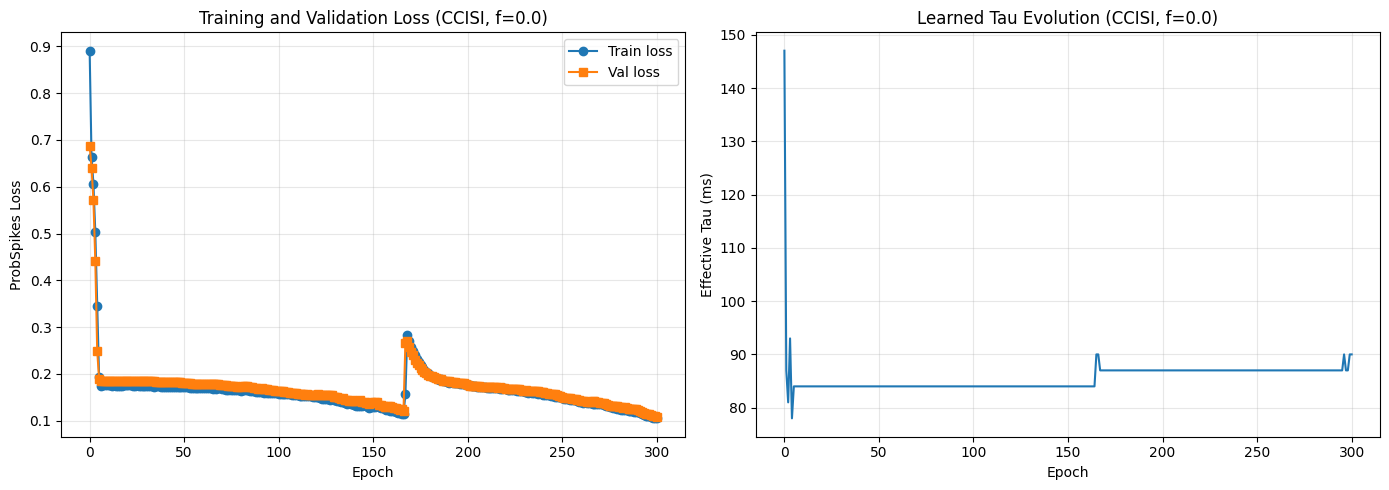


--- Training curves at f=0.2 ---


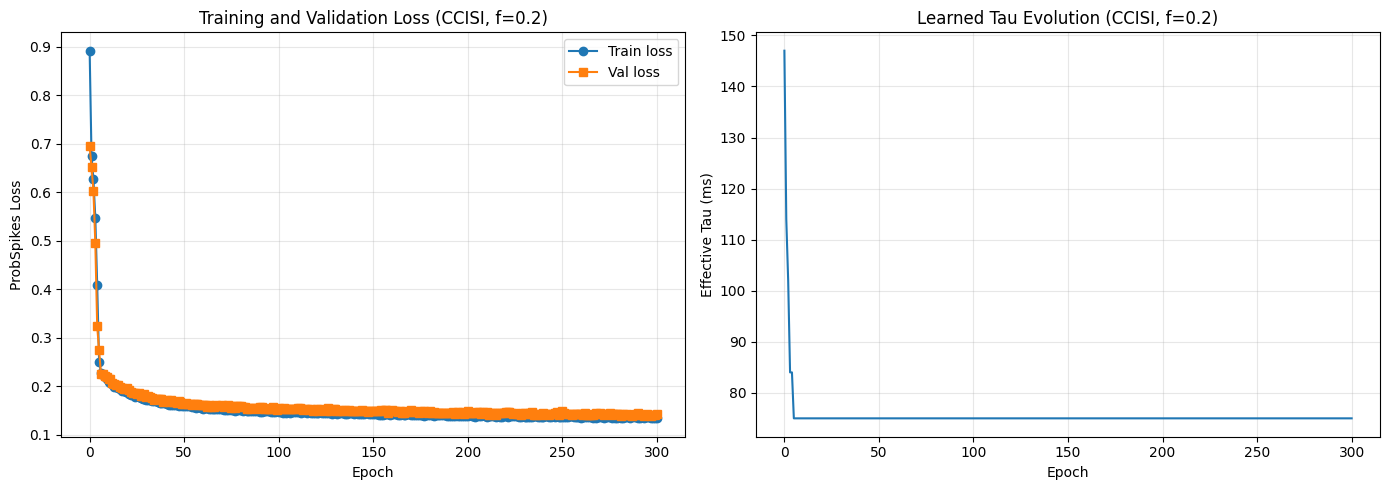


--- Training curves at f=0.4 ---


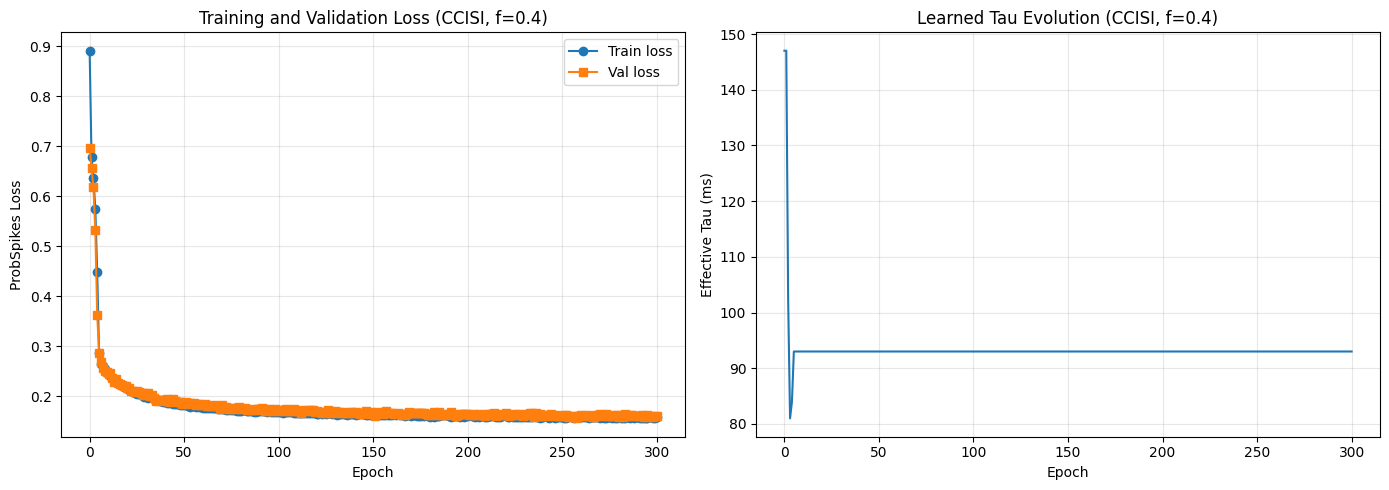


--- Training curves at f=0.6 ---


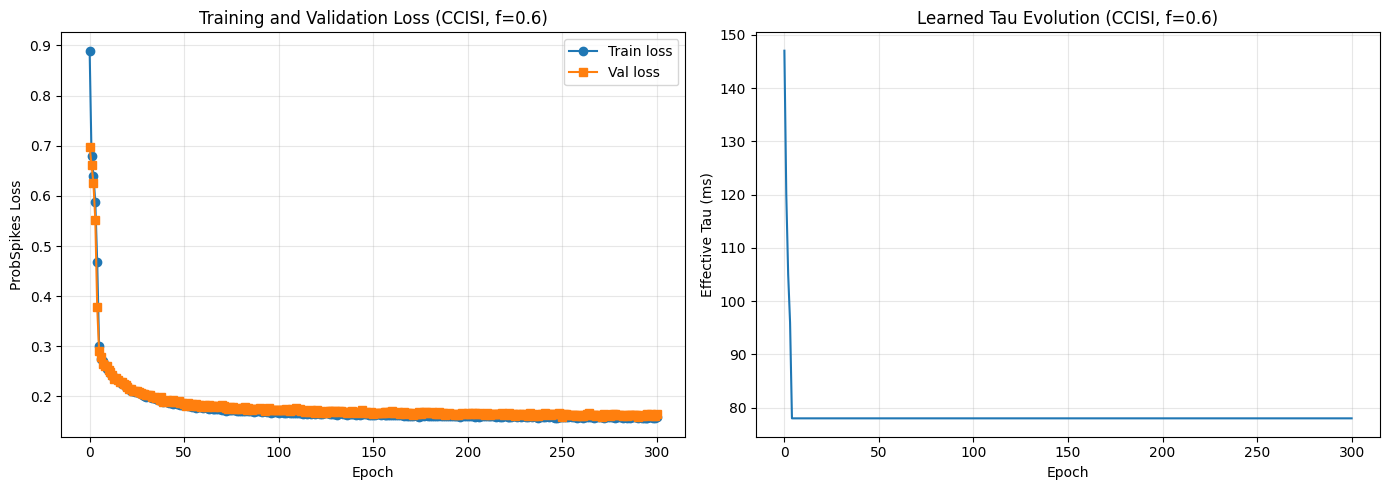


--- Training curves at f=0.8 ---


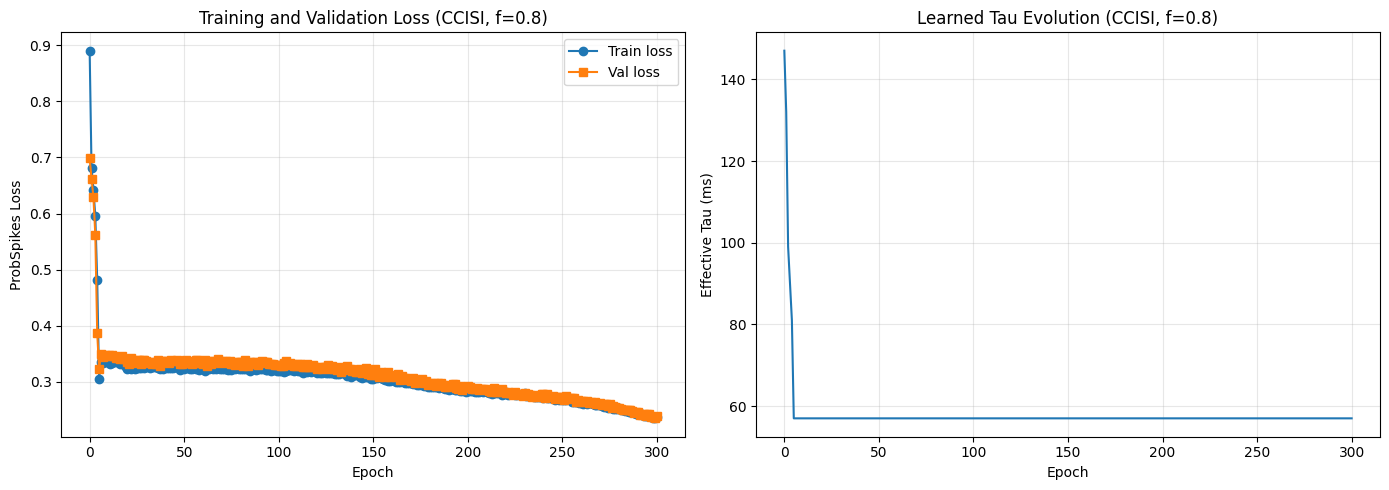


--- Training curves at f=1.0 ---


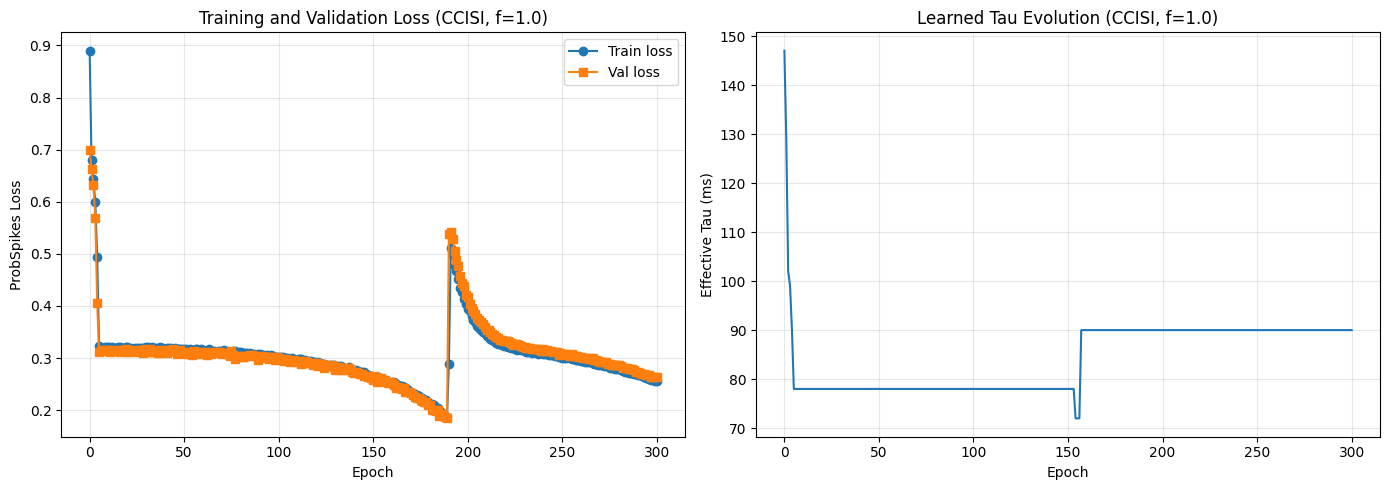

In [13]:
for f_val in F_VALUES:
    print(f"\n--- Training curves at f={f_val} ---")
    plot_training_curves(all_logs[f_val])

## 12. Sweep Summary

The sweep was already executed in §10 — one model trained per *f* and
evaluated at the same *f*. Print collected accuracies for inspection.

In [14]:
print("=== Train-at-f / Eval-at-f Sweep Summary (CCISI, learnable tau) ===")
for f_val in sorted(sweep_results.keys()):
    data = sweep_results[f_val]
    print(f"  f={f_val:.1f}:  accuracy = {data['mean']:.4f} +/- {data['std']:.4f}")

=== Train-at-f / Eval-at-f Sweep Summary (CCISI, learnable tau) ===
  f=0.0:  accuracy = 0.9963 +/- 0.0000
  f=0.2:  accuracy = 0.9932 +/- 0.0023
  f=0.4:  accuracy = 0.9870 +/- 0.0026
  f=0.6:  accuracy = 0.9833 +/- 0.0015
  f=0.8:  accuracy = 0.9673 +/- 0.0023
  f=1.0:  accuracy = 0.9556 +/- 0.0030


## 13. Plot Hidden-Perturbation Results

Figure saved to log/ccisi_tau_hidden_perturbation.png


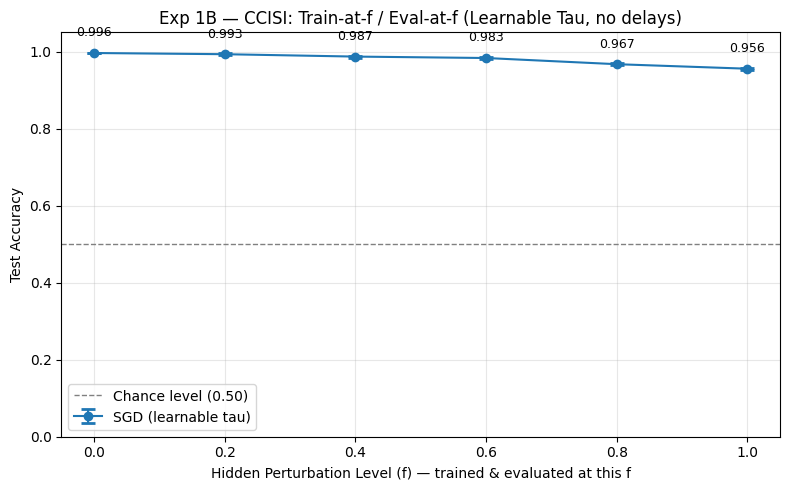

In [15]:
plot_hidden_perturbation_curve(
    sweep_results,
    save_path="log/ccisi_tau_hidden_perturbation.png",
)

## 14. Save Results

Save the perturbation sweep results and training log to JSON for:
- Later side-by-side comparison with `ccisi_delay.ipynb` (SGD-delay model).
- Comparison against the original input-perturbation baseline from Beyond Rate.

In [16]:
# Save perturbation sweep results
results_serialisable = {
    str(f_val): {
        "mean":   float(data["mean"]),
        "std":    float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

results_path = f"log/{MODEL_PREFIX}_hidden_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Perturbation results saved to {results_path}")

# Save per-f training logs
training_logs_serialisable = {
    str(f_val): {
        k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
        for k, vals in log.items()
    }
    for f_val, log in all_logs.items()
}
log_path = f"log/{MODEL_PREFIX}_training_log.json"
with open(log_path, "w") as fp:
    json.dump(training_logs_serialisable, fp, indent=2)
print(f"Training logs saved to {log_path}")

Perturbation results saved to log/ccisi_tau_hidden_perturbation_results.json
Training logs saved to log/ccisi_tau_training_log.json


## 15. Model Analysis

Inspect the learned tau and PSP filter shape to understand what temporal
scale the network adapted to for the CCISI task.

=== Learned Parameter Analysis (CCISI, learnable tau) ===

     f    effective tau (ms)
   0.0                 90.00
   0.2                 75.00
   0.4                 93.00
   0.6                 78.00
   0.8                 57.00
   1.0                 90.00

f=0 baseline — PSP filter: max=2.2491, mean=1.3737, length=50 taps


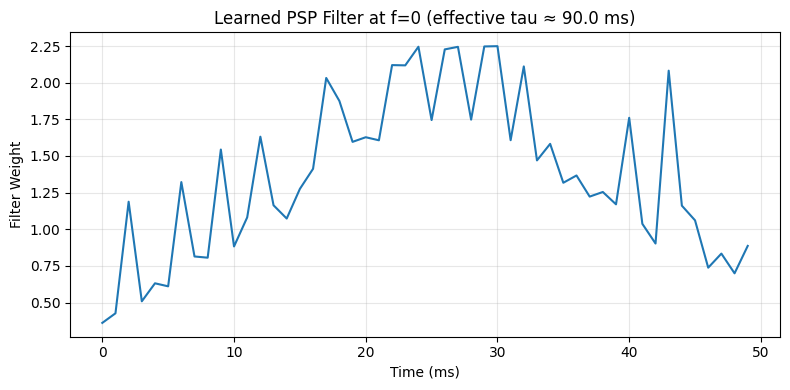


Weight statistics (f=0 baseline):
  fc1.weight_g: mean=5.7660, std=0.6485, shape=[100, 1, 1, 1, 1]
  fc1.weight_v: mean=-0.0199, std=1.2836, shape=[100, 20, 1, 1, 1]
  fc2.weight_g: mean=5.7694, std=0.0831, shape=[2, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.0941, std=0.5765, shape=[2, 100, 1, 1, 1]
  psp_filter.weight: mean=1.3737, std=0.5403, shape=[1, 1, 1, 1, 50]


In [17]:
print("=== Learned Parameter Analysis (CCISI, learnable tau) ===\n")

print(f"{'f':>6}  {'effective tau (ms)':>20}")
for f_val, mdl in all_models.items():
    print(f"{f_val:>6.1f}  {mdl.get_tau().item() / MS:>20.2f}")

# Detailed PSP filter plot for the f=0 baseline model
baseline = all_models[0.0]
tau_val = baseline.get_tau().item() / MS
filter_weights = baseline.psp_filter.weight.data.squeeze().cpu().numpy()
print(
    f"\nf=0 baseline — PSP filter: max={np.max(np.abs(filter_weights)):.4f}, "
    f"mean={np.mean(filter_weights):.4f}, length={len(filter_weights)} taps"
)

plt.figure(figsize=(8, 4))
plt.plot(np.flip(filter_weights))
plt.xlabel("Time (ms)")
plt.ylabel("Filter Weight")
plt.title(f"Learned PSP Filter at f=0 (effective tau ≈ {tau_val:.1f} ms)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Weight statistics for the f=0 baseline model
print("\nWeight statistics (f=0 baseline):")
for name, param in baseline.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"  {name}: mean={w.mean().item():.4f}, std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )

## 16. Summary and Interpretation

Print a concise summary of the experiment results and interpret the
accuracy-vs-f curve in the context of the CCISI temporal coding question.

In [18]:
print("=" * 62)
print("EXPERIMENT 1B SUMMARY: CCISI Hidden-Layer Perturbation")
print("Model: SGD with learnable tau (no delays)")
print("=" * 62)
print(f"{'f':>6}  {'Accuracy':>10}  {'Std':>8}")
print("-" * 30)
for f_val in sorted(sweep_results.keys()):
    data = sweep_results[f_val]
    print(f"{f_val:>6.1f}  {data['mean']:>10.4f}  {data['std']:>8.4f}")

# Accuracy drop from clean to fully-random hidden representation
acc_f0 = sweep_results[0.0]["mean"]
acc_f1 = sweep_results[1.0]["mean"]
drop   = acc_f0 - acc_f1
print(f"\nAccuracy drop (f=0 to f=1): {drop:.4f}")

if drop > 0.05:
    print("-> The hidden layer PRESERVES temporal structure.")
    print("   Cross-channel ISI information is maintained as a timing code.")
else:
    print("-> The hidden layer COLLAPSES temporal structure.")
    print("   Cross-channel ISI information has been converted to a rate code.")

print(f"\nOutput files in: log/")
print("Next step: run ccisi_delay.ipynb to compare with the SGD-delay model.")

EXPERIMENT 1B SUMMARY: CCISI Hidden-Layer Perturbation
Model: SGD with learnable tau (no delays)
     f    Accuracy       Std
------------------------------
   0.0      0.9963    0.0000
   0.2      0.9932    0.0023
   0.4      0.9870    0.0026
   0.6      0.9833    0.0015
   0.8      0.9673    0.0023
   1.0      0.9556    0.0030

Accuracy drop (f=0 to f=1): 0.0407
-> The hidden layer COLLAPSES temporal structure.
   Cross-channel ISI information has been converted to a rate code.

Output files in: log/
Next step: run ccisi_delay.ipynb to compare with the SGD-delay model.
